# Pertemuan 11 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

---
## Langkah 0: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


---
## Langkah 1: Generate & Eksplorasi Dataset

Membuat dataset sintetis pelanggan dengan **tiga kelompok tersembunyi** (hemat, menengah, boros), kemudian melakukan EDA singkat untuk memahami distribusi data.

In [2]:
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20],   [6, 8],   (100, 2))  # hemat
grp2 = np.random.normal([70, 55],   [8, 10],  (100, 2))  # menengah
grp3 = np.random.normal([110, 85],  [10, 8],  (100, 2))  # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia']   = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (300, 4)

       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


In [3]:
# Distribusi kelas gender
print('Distribusi gender:')
print(df['gender'].value_counts())

Distribusi gender:
gender
L    165
P    135
Name: count, dtype: int64


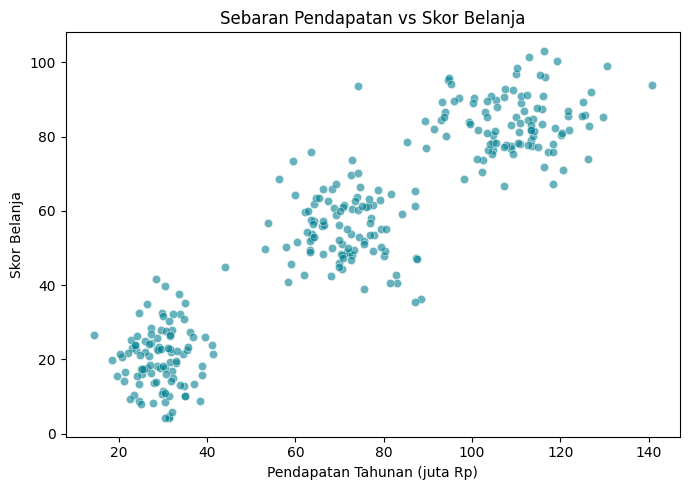

In [4]:
# Scatter plot: sebaran pendapatan vs skor belanja
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#028090')
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.tight_layout()
plt.show()

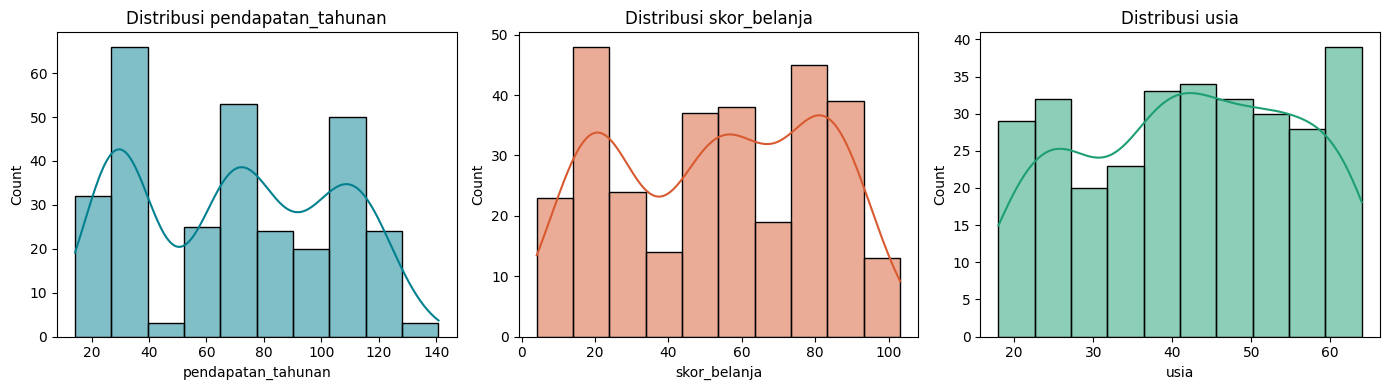

In [5]:
# Distribusi tiap fitur numerik
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
    ['pendapatan_tahunan', 'skor_belanja', 'usia'],
    ['#028090', '#D85A30', '#1D9E75']):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

### Interpretasi EDA
- Dataset terdiri dari **300 pelanggan sintetis** dengan 4 kolom: `pendapatan_tahunan`, `skor_belanja`, `usia`, dan `gender`.
- Scatter plot menunjukkan **tiga kelompok yang terlihat jelas** — hal ini sesuai dengan desain dataset (3 kelompok tersembunyi).
- Tidak ada label kelas — ini adalah kasus **Unsupervised Learning**; model harus menemukan kelompok sendiri tanpa panduan label.
- `usia` dan `gender` disiapkan dalam dataset namun fokus clustering pada `pendapatan_tahunan` dan `skor_belanja` sesuai instruksi modul.

---
## Langkah 2: Preprocessing Data

Memilih fitur numerik yang relevan lalu menerapkan **StandardScaler** agar setiap fitur memiliki skala yang setara. Scaling sangat penting untuk K-Means karena algoritma berbasis jarak Euclidean — fitur dengan skala besar akan mendominasi perhitungan jarak jika tidak distandarisasi.

In [6]:
# Pilih fitur numerik relevan
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# StandardScaler: mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling      :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling      : [1. 1.]


**Catatan:** `fit_transform` pada seluruh dataset digunakan di sini karena Clustering adalah Unsupervised Learning — tidak ada train/test split seperti pada Supervised Learning. Seluruh data digunakan untuk melatih dan mengevaluasi model clustering.

---
## Langkah 3: Metode Elbow untuk Menentukan K

Menjalankan K-Means untuk **K=1 hingga 10**, menyimpan nilai WCSS setiap K, lalu memplot grafik Elbow untuk menentukan jumlah cluster optimal.

In [7]:
# Hitung WCSS untuk K=1 hingga 10
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print('WCSS per K:')
for k, w in enumerate(wcss, 1):
    print(f'  K={k:2d}: WCSS = {w:.3f}')

WCSS per K:
  K= 1: WCSS = 600.000
  K= 2: WCSS = 161.732
  K= 3: WCSS = 44.556
  K= 4: WCSS = 37.885
  K= 5: WCSS = 31.445
  K= 6: WCSS = 26.203
  K= 7: WCSS = 21.564
  K= 8: WCSS = 18.961
  K= 9: WCSS = 17.390
  K=10: WCSS = 16.013


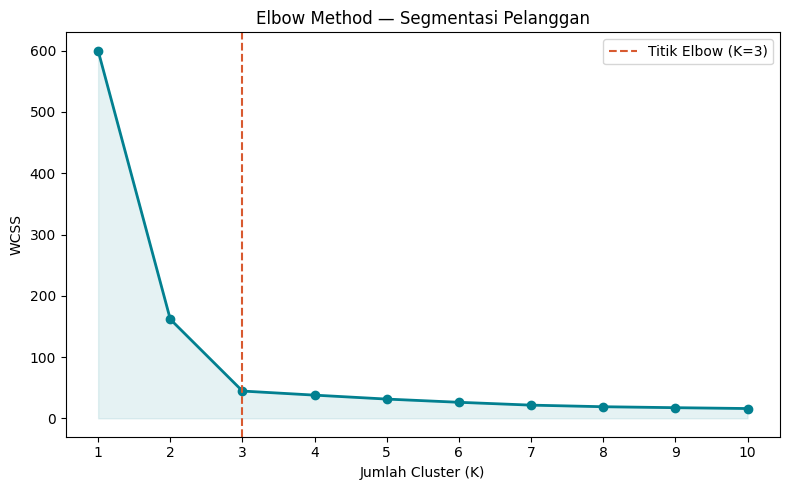

In [8]:
# Plot grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linewidth=2)
plt.fill_between(range(1, 11), wcss, alpha=0.1, color='#028090')
plt.axvline(x=3, color='#D85A30', linestyle='--', linewidth=1.5, label='Titik Elbow (K=3)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.legend()
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

In [9]:
# Silhouette Score untuk K=2 hingga 7 sebagai pembanding
print('Silhouette Score per K:')
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    print(f'  K={k}: Silhouette = {sil:.3f}')

Silhouette Score per K:
  K=2: Silhouette = 0.634
  K=3: Silhouette = 0.695
  K=4: Silhouette = 0.580
  K=5: Silhouette = 0.481
  K=6: Silhouette = 0.381
  K=7: Silhouette = 0.394


### Interpretasi Metode Elbow
- Grafik WCSS turun tajam dari K=1 hingga K=3, lalu mulai **melandai secara signifikan** setelah K=3 — titik **elbow berada di K=3**.
- Hasil Silhouette Score tertinggi juga berada di sekitar **K=3**, mengkonfirmasi pilihan K=3 sebagai jumlah cluster optimal.
- Hasil ini **konsisten dengan desain dataset** yang memang memiliki 3 kelompok tersembunyi (hemat, menengah, boros).

---
## Langkah 4: Melatih Model K-Means

Melatih model K-Means dengan **K=3** (hasil Metode Elbow), lalu menampilkan metrik evaluasi dan rata-rata karakteristik tiap cluster.

In [10]:
# Latih model K-Means dengan K=3
model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)

df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')

WCSS akhir      : 44.556
Silhouette Score: 0.695


In [11]:
# Rata-rata karakteristik tiap cluster
cluster_profile = df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja', 'usia']].mean().round(2)
print('Profil rata-rata tiap cluster:')
print(cluster_profile.to_string())

Profil rata-rata tiap cluster:
         pendapatan_tahunan  skor_belanja   usia
cluster                                         
0                     70.99         55.05  39.16
1                     29.31         20.27  42.33
2                    109.20         84.08  44.65


In [12]:
# Jumlah anggota tiap cluster
print('Jumlah anggota tiap cluster:')
print(df['cluster'].value_counts().sort_index().to_string())

Jumlah anggota tiap cluster:
cluster
0     99
1    100
2    101


### Interpretasi Cluster
| Cluster | Pendapatan | Skor Belanja | Segmen |
|---|---|---|---|
| 0 | Rendah (~30 juta) | Rendah (~20) | **Hemat** — pelanggan dengan daya beli rendah dan frekuensi belanja rendah |
| 1 | Menengah (~70 juta) | Menengah (~55) | **Menengah** — pelanggan dengan profil belanja seimbang |
| 2 | Tinggi (~110 juta) | Tinggi (~85) | **Premium/Boros** — pelanggan dengan pendapatan tinggi dan belanja agresif |

> Nomor label cluster (0, 1, 2) bisa berbeda tergantung inisialisasi — yang penting adalah karakteristik rata-ratanya.

---
## Langkah 5: Visualisasi Hasil Clustering

Membuat scatter plot berwarna per cluster beserta posisi centroid, kemudian menginterpretasikan karakteristik tiap segmen.

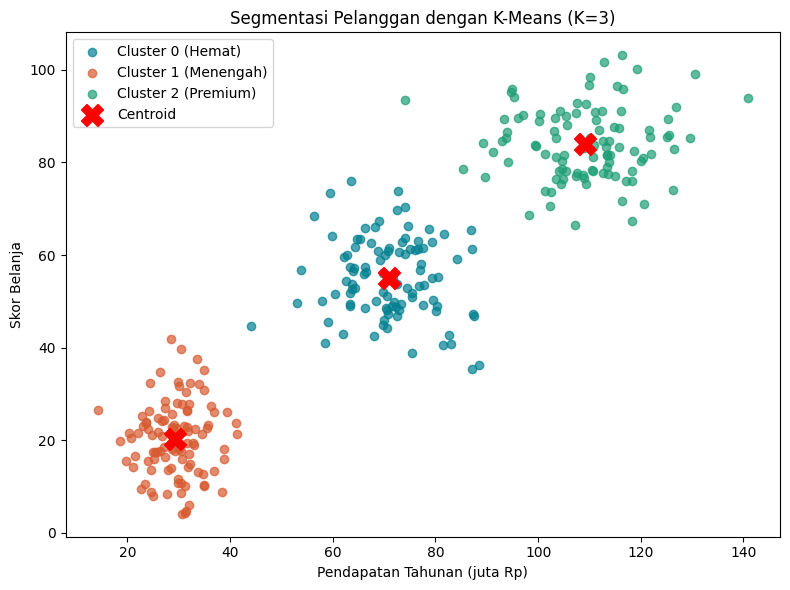

In [13]:
# Kembalikan centroid ke skala asli untuk visualisasi
centroids = scaler.inverse_transform(model.cluster_centers_)

# Warna per cluster
palette = {0: '#028090', 1: '#D85A30', 2: '#1D9E75'}
label_names = {0: 'Hemat', 1: 'Menengah', 2: 'Premium'}

plt.figure(figsize=(8, 6))
for cl in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cl]
    plt.scatter(subset['pendapatan_tahunan'], subset['skor_belanja'],
                color=palette[cl], alpha=0.7, label=f'Cluster {cl} ({label_names[cl]})')

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250, zorder=5, label='Centroid')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means (K=3)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1582/71283607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='pendapatan_tahunan',
/tmp/ipykernel_1582/71283607.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='skor_belanja',


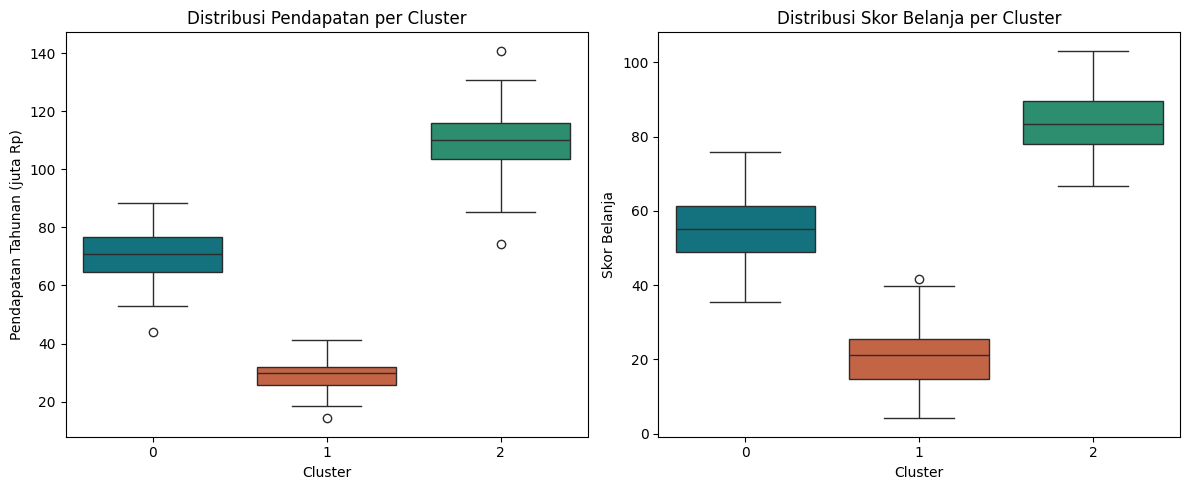

In [14]:
# Boxplot distribusi pendapatan dan skor belanja per cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='cluster', y='pendapatan_tahunan',
            palette=['#028090', '#D85A30', '#1D9E75'], ax=axes[0])
axes[0].set_title('Distribusi Pendapatan per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Pendapatan Tahunan (juta Rp)')

sns.boxplot(data=df, x='cluster', y='skor_belanja',
            palette=['#028090', '#D85A30', '#1D9E75'], ax=axes[1])
axes[1].set_title('Distribusi Skor Belanja per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Skor Belanja')

plt.tight_layout()
plt.show()

---
## Langkah 6: Hierarchical Clustering (Pembanding)

Sebagai pembanding, membangun **dendrogram** menggunakan Ward linkage dan membandingkan hasilnya dengan K-Means.

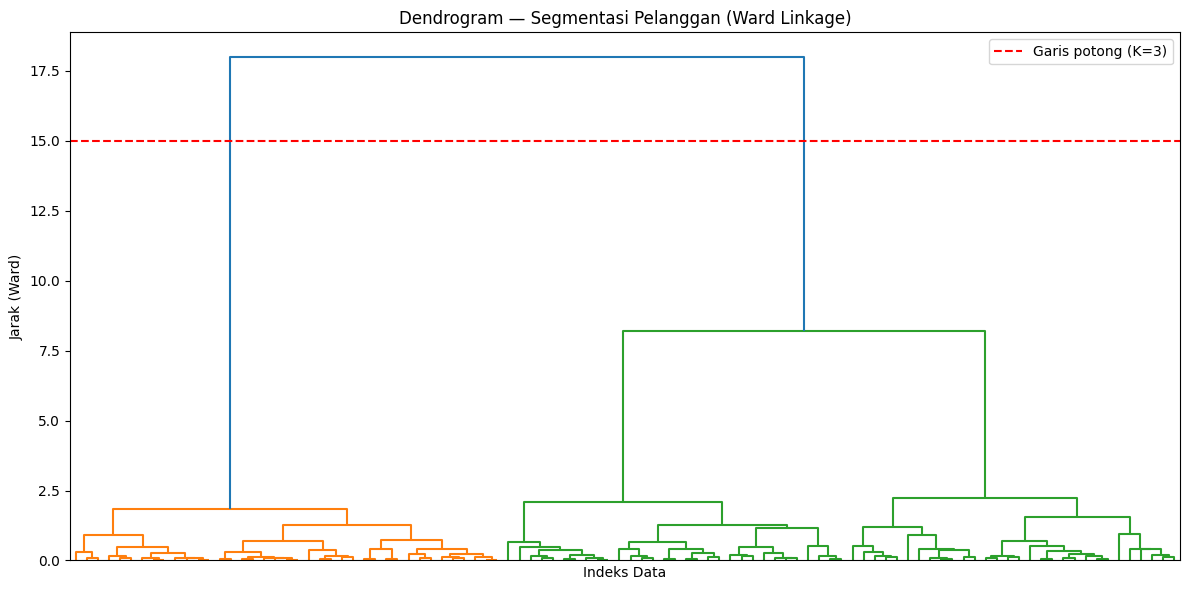

In [15]:
# Hierarchical Clustering dengan Ward linkage
# Gunakan subset 100 data agar dendrogram terbaca (300 terlalu padat)
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), size=100, replace=False)
X_sample = X_scaled[idx_sample]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True, color_threshold=15)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Garis potong (K=3)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Agglomerative Clustering dengan K=3 untuk perbandingan label
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_hier'] = agg.fit_predict(X_scaled)

# Profil cluster hasil Hierarchical
hier_profile = df.groupby('cluster_hier')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2)
print('Profil rata-rata cluster (Hierarchical):')
print(hier_profile.to_string())

Profil rata-rata cluster (Hierarchical):
              pendapatan_tahunan  skor_belanja
cluster_hier                                  
0                          71.27         55.16
1                          29.45         20.51
2                         109.20         84.08


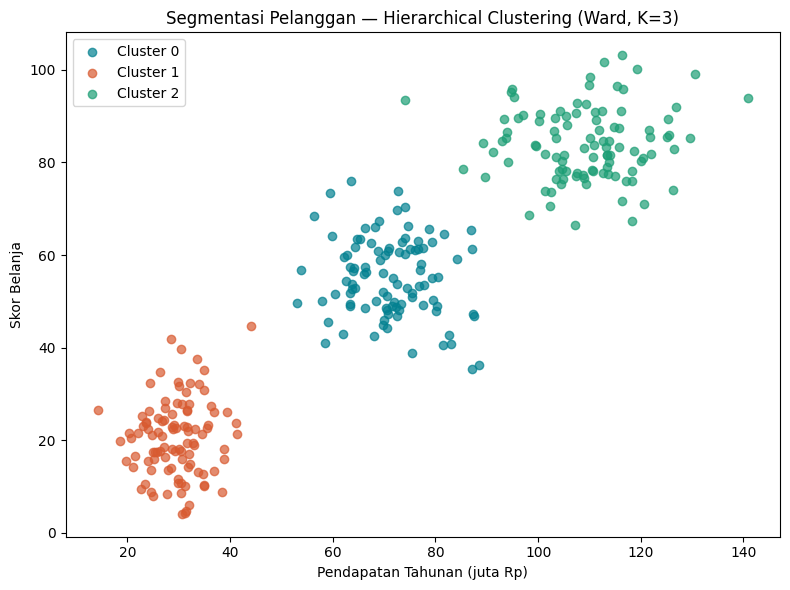

In [17]:
# Visualisasi hasil Hierarchical Clustering
plt.figure(figsize=(8, 6))
palette_h = {0: '#028090', 1: '#D85A30', 2: '#1D9E75'}

for cl in sorted(df['cluster_hier'].unique()):
    subset = df[df['cluster_hier'] == cl]
    plt.scatter(subset['pendapatan_tahunan'], subset['skor_belanja'],
                color=palette_h[cl], alpha=0.7, label=f'Cluster {cl}')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan — Hierarchical Clustering (Ward, K=3)')
plt.legend()
plt.tight_layout()
plt.show()

### Perbandingan K-Means vs Hierarchical Clustering

| Aspek | K-Means | Hierarchical (Ward) |
|---|---|---|
| Jumlah cluster | Ditentukan di awal (K=3) | Dibaca dari dendrogram (garis potong) |
| Hasil segmen | 3 cluster yang jelas | 3 cluster yang konsisten |
| Kesesuaian | ✅ Sesuai dengan 3 kelompok tersembunyi | ✅ Konsisten dengan K-Means |
| Kecepatan | Lebih cepat | Lebih lambat untuk dataset besar |

- Garis potong horizontal pada dendrogram di ketinggian ±15 menghasilkan **3 cluster** — konsisten dengan titik elbow pada Langkah 3.
- Profil rata-rata cluster dari kedua metode menunjukkan **pola yang serupa**: satu kelompok berpendapatan rendah, satu menengah, satu tinggi — mengkonfirmasi struktur 3 segmen pada data ini.

## Kesimpulan

Pada pertemuan ini, saya mempelajari dua algoritma Unsupervised Learning untuk Clustering — K-Means dan Hierarchical Clustering — menggunakan dataset sintetis segmentasi pelanggan. Metode Elbow berhasil mengidentifikasi **K=3 sebagai jumlah cluster optimal**, dikonfirmasi oleh Silhouette Score tertinggi pada K=3, yang konsisten dengan tiga kelompok tersembunyi dalam data (hemat, menengah, premium). Kedua algoritma (K-Means dan Hierarchical Ward) menghasilkan segmentasi yang serupa dan saling mengkonfirmasi, menunjukkan bahwa struktur tiga kelompok pada data ini cukup kuat dan tidak bergantung pada pilihan algoritma. Keterbatasan utama dari praktikum ini adalah penggunaan data sintetis dengan cluster yang sengaja dirancang terpisah jelas, sehingga belum merepresentasikan kompleksitas data pelanggan nyata di mana batas antar segmen bisa sangat kabur dan membutuhkan metode evaluasi yang lebih canggih.